# 👁️ Eye Disease Detection - Model Training
### MobileNetV2 + Transfer Learning
#### ⚠️ Run 1_data_cleaning.ipynb first before this file
---

## Cell 1 - Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

✅ Libraries imported successfully!
TensorFlow version: 2.20.0


## Cell 2 - Configuration & Settings

In [2]:
# ======================================
# ⚠️ Change these paths to match yours
# ======================================
TRAIN_DIR = r'D:\New folder\data\train'  # Training folder path
TEST_DIR  = r'D:\New folder\data\test'     # Testing folder path

# Model settings
IMG_SIZE    = 224       # Image size (MobileNetV2 requires 224x224)
BATCH_SIZE  = 32        # Number of images per batch
EPOCHS      = 30        # Number of training epochs
NUM_CLASSES = 2         # Number of classes (cataract - normal)
LEARNING_RATE = 0.0001  # Learning rate

# Verify dataset
for split in ['train', 'test']:
    path = TRAIN_DIR if split == 'train' else TEST_DIR
    print(f'\n📂 {split.upper()}:')
    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            print(f'   {cls}: {count} images')

print('\n✅ Settings configured!')


📂 TRAIN:
   cataract: 1410 images
   normal: 1179 images

📂 TEST:
   cataract: 354 images
   normal: 295 images

✅ Settings configured!


## Cell 3 - Data Preparation & Augmentation

In [3]:
# Data Augmentation for Training
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize images
    rotation_range=20,        # Random rotation
    width_shift_range=0.1,    # Horizontal shift
    height_shift_range=0.1,   # Vertical shift
    shear_range=0.1,          # Shear
    zoom_range=0.1,           # Zoom in/out
    horizontal_flip=True,     # Horizontal flip
    brightness_range=[0.8, 1.2],  # Brightness variation
    fill_mode='nearest'
)

# Test set - only normalization, no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# Load data
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Print class info
CLASS_NAMES = list(train_generator.class_indices.keys())
print(f'\n📌 Classes: {CLASS_NAMES}')
print(f'📌 Indices: {train_generator.class_indices}')
print(f'\n✅ Data loaded successfully!')
print(f'   Training samples  : {train_generator.samples}')
print(f'   Testing samples   : {test_generator.samples}')

Found 2589 images belonging to 2 classes.
Found 649 images belonging to 2 classes.

📌 Classes: ['cataract', 'normal']
📌 Indices: {'cataract': 0, 'normal': 1}

✅ Data loaded successfully!
   Training samples  : 2589
   Testing samples   : 649


## Cell 4 - Visualize Sample Images

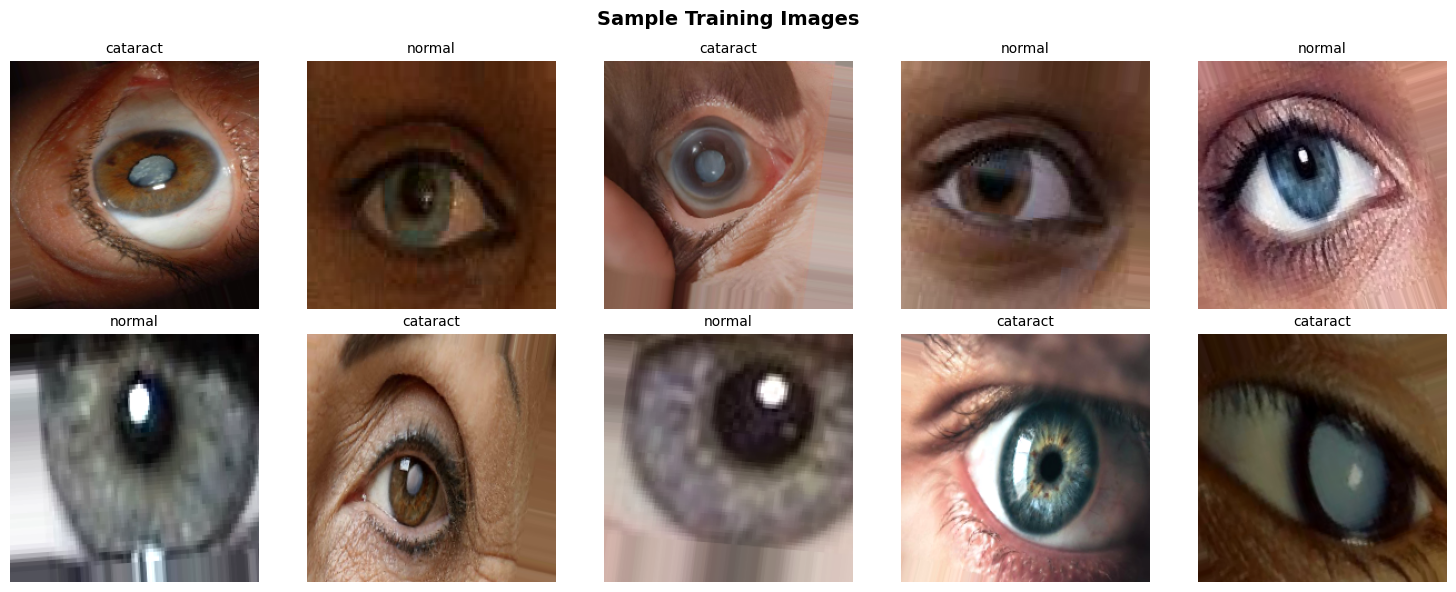

✅ Sample images displayed!


In [4]:
# عرض 10 صور من الداتا
images, labels = next(train_generator)

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i])
    label_idx = np.argmax(labels[i])
    plt.title(CLASS_NAMES[label_idx], fontsize=10)
    plt.axis('off')

plt.suptitle('Sample Training Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ Sample images displayed!')

## Cell 5 - Build Model with MobileNetV2

In [5]:
def build_model(num_classes, img_size, learning_rate):
    """
    بناء موديل Transfer Learning باستخدام MobileNetV2
    """
    # تحميل MobileNetV2 بدون الـ top layers
    base_model = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'  # أوزان مدربة على ImageNet
    )
    
    # تجميد الـ base model في البداية
    base_model.trainable = False
    
    # إضافة الـ custom layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=output)
    
    # compile الموديل
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model, base_model

# بناء الموديل
model, base_model = build_model(NUM_CLASSES, IMG_SIZE, LEARNING_RATE)

print('✅ Model built successfully!')
print(f'   Total parameters    : {model.count_params():,}')
print(f'   Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')
model.summary()

✅ Model built successfully!
   Total parameters    : 2,624,194
   Trainable parameters: 363,650


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,624,194 (10.01 MB)

 Trainable params: 363,650 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## Cell 6 - Setup Callbacks

In [6]:
# Callbacks لتحسين التدريب
callbacks = [
    # وقف التدريب لو الموديل مش بيتحسن
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    # حفظ أحسن موديل
    ModelCheckpoint(
        'best_eye_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # تقليل الـ Learning Rate لو الموديل وقف
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print('✅ Callbacks configured!')

✅ Callbacks configured!


## Cell 7 - Phase 1: Training (Feature Extraction)

In [7]:
print('🚀 Phase 1: Training custom layers only...')
print('=' * 50)

history_phase1 = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Phase 1 complete!')
best_val_acc = max(history_phase1.history['val_accuracy'])
print(f'   Best Validation Accuracy: {best_val_acc*100:.2f}%')

🚀 Phase 1: Training custom layers only...
Epoch 1/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6606 - loss: 0.7703     
Epoch 1: val_accuracy improved from None to 0.87057, saving model to best_eye_model.h5


81/81 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.7277 - loss: 0.6219 - val_accuracy: 0.8706 - val_loss: 0.3576 - learning_rate: 1.0000e-04
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8249 - loss: 0.4496     
Epoch 2: val_accuracy improved from 0.87057 to 0.88444, saving model to best_eye_model.h5


81/81 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.8301 - loss: 0.4378 - val_accuracy: 0.8844 - val_loss: 0.2958 - learning_rate: 1.0000e-04
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8421 - loss: 0.4053  
Epoch 3: val_accuracy improved from 0.88444 to 0.90293, saving model to best_eye_model.h5


81/81 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.8401 - loss: 0.3960 - val_accuracy: 0.9029 - val_loss: 0.2578 - learning_rate: 1.0000e-04
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 987ms/step - accuracy: 0.8641 - loss: 0.3323  
Epoch 4: val_accuracy improved from 0.90293 to 0.90909, saving model to best_eye_model.h5


81/81 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.8590 - loss: 0.3427 - val_accuracy: 0.9091 - val_loss: 0.2508 - learning_rate: 1.0000e-04
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 994ms/step - accuracy: 0.8527 - loss: 0.3698  
Epoch 5: val_accuracy did not improve from 0.90909
81/81 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.8722 - loss: 0.3278 - val_accuracy: 0.9076 - val_loss: 0.2485 - learning_rate: 1.0000e-04
Epoch 6/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8834 - loss: 0.3154      
Epoch 6: val_accuracy did not improve from 0.90909
81/81 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.8841 - loss: 0.3070 - val_accuracy: 0.9091 - val_loss: 0.2410 - learning_rate: 1.0000e-04
Epoch 7/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8775 - loss: 0.3007     
Epoch 7: val_accuracy improved from 0.90909 to 0.91371, saving model to best_eye_model.h5


81/81 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.8822 - loss: 0.3080 - val_accuracy: 0.9137 - val_loss: 0.2341 - learning_rate: 1.0000e-04
Epoch 8/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8791 - loss: 0.3223  
Epoch 8: val_accuracy improved from 0.91371 to 0.91988, saving model to best_eye_model.h5


81/81 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.8891 - loss: 0.3021 - val_accuracy: 0.9199 - val_loss: 0.2271 - learning_rate: 1.0000e-04
Epoch 9/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8972 - loss: 0.2909     
Epoch 9: val_accuracy did not improve from 0.91988
81/81 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.9011 - loss: 0.2846 - val_accuracy: 0.9153 - val_loss: 0.2256 - learning_rate: 1.0000e-04
Epoch 10/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 982ms/step - accuracy: 0.8998 - loss: 0.2608  
Epoch 10: val_accuracy did not improve from 0.91988
81/81 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8992 - loss: 0.2685 - val_accuracy: 0.9183 - val_loss: 0.2224 - learning_rate: 1.0000e-04
Epoch 11/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 894ms/step - accuracy: 0.8958 - loss: 0.2840  
Epoch 11: val_accuracy did not improve from 0.91988
81/81 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9011 - loss: 0.2675 - val_accuracy: 0.9168 - val_loss: 0.2249 - learning_rate: 1.0000e-04
Epoc

81/81 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9011 - loss: 0.2607 - val_accuracy: 0.9214 - val_loss: 0.2181 - learning_rate: 1.0000e-04
Epoch 15/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 984ms/step - accuracy: 0.9219 - loss: 0.2088  
Epoch 15: val_accuracy did not improve from 0.92142
81/81 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9146 - loss: 0.2337 - val_accuracy: 0.9199 - val_loss: 0.2139 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 14.

✅ Phase 1 complete!
   Best Validation Accuracy: 92.14%


## Cell 8 - Phase 2: Fine-Tuning

In [8]:
print('🔧 Phase 2: Fine-tuning...')
print('=' * 50)

# فتح آخر 30 layer في الـ base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# إعادة compile بـ learning rate أصغر
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE / 10),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Phase 2 complete!')
best_val_acc = max(history_phase2.history['val_accuracy'])
print(f'   Best Validation Accuracy: {best_val_acc*100:.2f}%')

🔧 Phase 2: Fine-tuning...
Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8559 - loss: 0.3326     
Epoch 1: val_accuracy did not improve from 0.92142
81/81 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.8660 - loss: 0.3151 - val_accuracy: 0.9214 - val_loss: 0.2105 - learning_rate: 1.0000e-05
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8763 - loss: 0.3100  
Epoch 2: val_accuracy improved from 0.92142 to 0.92758, saving model to best_eye_model.h5


81/81 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.8772 - loss: 0.3119 - val_accuracy: 0.9276 - val_loss: 0.2124 - learning_rate: 1.0000e-05
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9006 - loss: 0.2642  
Epoch 3: val_accuracy did not improve from 0.92758
81/81 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.8919 - loss: 0.2850 - val_accuracy: 0.9276 - val_loss: 0.2104 - learning_rate: 1.0000e-05
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - accuracy: 0.9092 - loss: 0.2572  
Epoch 4: val_accuracy did not improve from 0.92758

Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
81/81 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9019 - loss: 0.2665 - val_accuracy: 0.9245 - val_loss: 0.2119 - learning_rate: 1.0000e-05
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 955ms/step - accuracy: 0.9158 - loss: 0.2402  
Epoch 5: val_accuracy did not improve from 0.92758
81/81 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9108 - loss: 0.2539 - val

81/81 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.9096 - loss: 0.2403 - val_accuracy: 0.9307 - val_loss: 0.2050 - learning_rate: 2.0000e-06
Epoch 9/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 920ms/step - accuracy: 0.9069 - loss: 0.2589  
Epoch 9: val_accuracy did not improve from 0.93066
81/81 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9065 - loss: 0.2534 - val_accuracy: 0.9307 - val_loss: 0.2047 - learning_rate: 2.0000e-06
Epoch 10/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9026 - loss: 0.2599     
Epoch 10: val_accuracy did not improve from 0.93066
81/81 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9054 - loss: 0.2551 - val_accuracy: 0.9307 - val_loss: 0.2043 - learning_rate: 2.0000e-06
Epoch 11/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8949 - loss: 0.2619     
Epoch 11: val_accuracy did not improve from 0.93066
81/81 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.9050 - loss: 0.2511 - val_accuracy: 0.9291 - val_loss: 0.2040 - learning_rate: 2.0000e-06
Epoch 1

81/81 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9092 - loss: 0.2394 - val_accuracy: 0.9322 - val_loss: 0.2035 - learning_rate: 2.0000e-06
Epoch 13/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 971ms/step - accuracy: 0.9091 - loss: 0.2452  
Epoch 13: val_accuracy improved from 0.93220 to 0.93374, saving model to best_eye_model.h5


81/81 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9088 - loss: 0.2480 - val_accuracy: 0.9337 - val_loss: 0.2035 - learning_rate: 2.0000e-06
Epoch 14/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 949ms/step - accuracy: 0.9197 - loss: 0.2333  
Epoch 14: val_accuracy did not improve from 0.93374
81/81 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9112 - loss: 0.2508 - val_accuracy: 0.9322 - val_loss: 0.2028 - learning_rate: 2.0000e-06
Epoch 15/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 906ms/step - accuracy: 0.9029 - loss: 0.2714  
Epoch 15: val_accuracy did not improve from 0.93374
81/81 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9092 - loss: 0.2515 - val_accuracy: 0.9307 - val_loss: 0.2029 - learning_rate: 2.0000e-06
Epoch 16/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9096 - loss: 0.2456     
Epoch 16: val_accuracy did not improve from 0.93374
81/81 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.9139 - loss: 0.2353 - val_accuracy: 0.9291 - val_loss: 0.2029 - learning_rate: 2.0000e-06
Epoch

## Cell 9 - Plot Training Curves

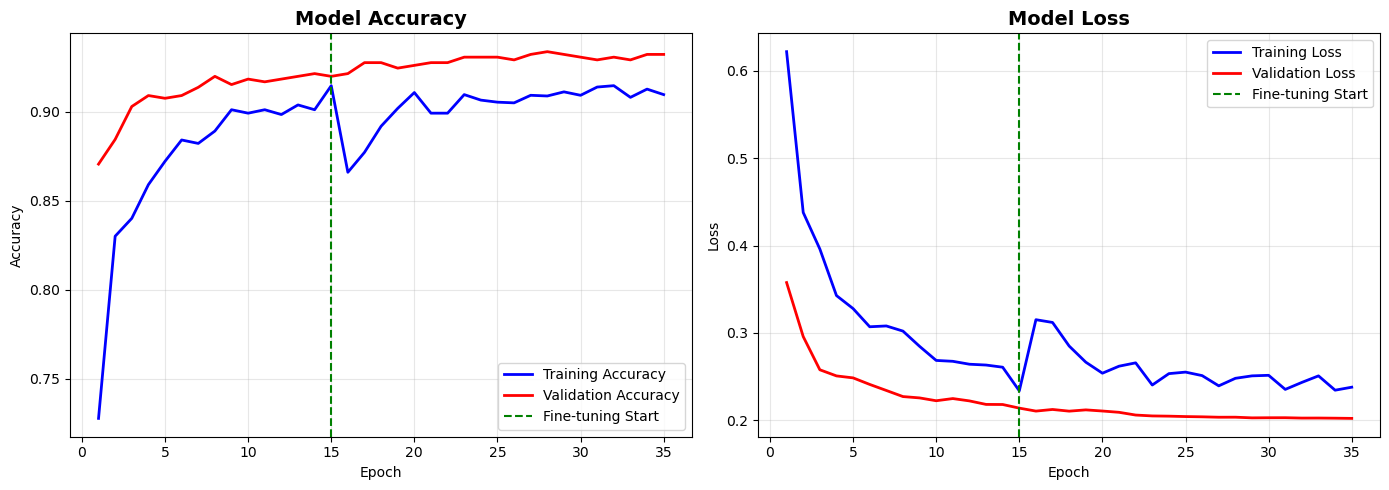

✅ Training curves saved!


In [9]:
def plot_history(h1, h2):
    # دمج الـ history
    acc     = h1.history['accuracy']     + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss    = h1.history['loss']         + h2.history['loss']
    val_loss= h1.history['val_loss']     + h2.history['val_loss']
    epochs  = range(1, len(acc) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy
    axes[0].plot(epochs, acc,     'b-', label='Training Accuracy',   linewidth=2)
    axes[0].plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
    axes[0].axvline(x=len(h1.history['accuracy']), color='green', linestyle='--', label='Fine-tuning Start')
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss
    axes[1].plot(epochs, loss,     'b-', label='Training Loss',   linewidth=2)
    axes[1].plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
    axes[1].axvline(x=len(h1.history['loss']), color='green', linestyle='--', label='Fine-tuning Start')
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Training curves saved!')

plot_history(history_phase1, history_phase2)

## Cell 10 - Model Evaluation

In [10]:
print('📊 Evaluating model on test set...')
print('=' * 50)

# تقييم على الـ test set
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f'\n🎯 Test Accuracy : {test_acc*100:.2f}%')
print(f'📉 Test Loss     : {test_loss:.4f}')

# Classification Report
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

print('\n📋 Classification Report:')
print('=' * 50)
# ✅ تصحيح: بدون target_names عشان متعملش error لو عدد الكلاسات مختلف
print(classification_report(y_true, y_pred))

📊 Evaluating model on test set...

🎯 Test Accuracy : 93.37%
📉 Test Loss     : 0.2035
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 547ms/step

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       354
           1       0.89      0.98      0.93       295

    accuracy                           0.93       649
   macro avg       0.93      0.94      0.93       649
weighted avg       0.94      0.93      0.93       649



## Cell 11 - Confusion Matrix

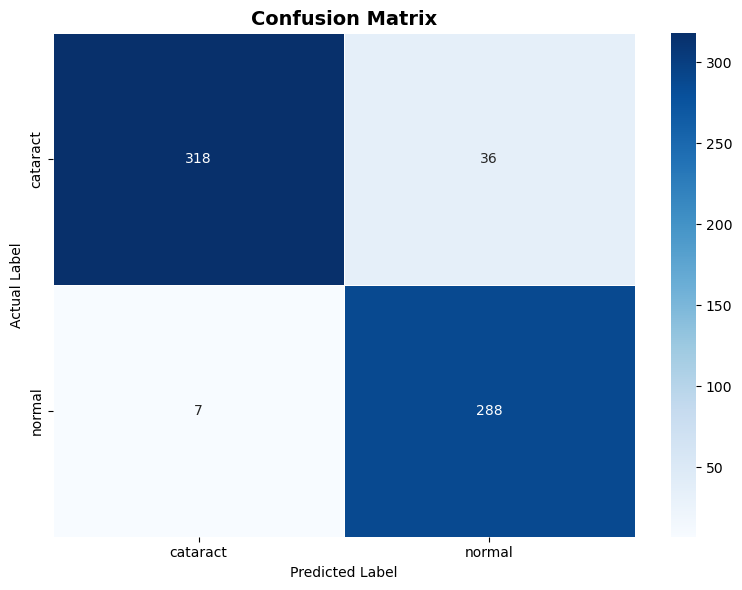

✅ Confusion matrix saved!


In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5
)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('✅ Confusion matrix saved!')

## Cell 12 - Prediction Function

In [12]:
def predict_eye_disease(image_path, model, class_names, img_size=224):
    """
    Predict eye disease from image.
    Displays result in a clean scan-result style.
    """
    # Load and preprocess image
    img            = cv2.imread(image_path)
    img_rgb        = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized    = cv2.resize(img_rgb, (img_size, img_size))
    img_normalized = img_resized / 255.0
    img_expanded   = np.expand_dims(img_normalized, axis=0)

    # Predict
    preds         = model.predict(img_expanded, verbose=0)
    predicted_idx = np.argmax(preds[0])
    confidence    = preds[0][predicted_idx] * 100
    diagnosis     = class_names[predicted_idx]

    # Style
    is_cataract  = diagnosis == 'cataract'
    label        = 'Cataract Detected' if is_cataract else 'Normal'
    icon         = '⚠️' if is_cataract else '✅'
    bar_color    = '#FF8C00' if is_cataract else '#2ECC71'
    bg_color     = '#FFF3E0' if is_cataract else '#E8F8F0'

    # Recommendations
    if is_cataract:
        recommendations = [
            'Attend Regular Eye Check-Ups.',
            'Avoid Eye Irritants.',
            'Maintain A Healthy Diet For The Eyes.',
            'Report Any Vision Changes Immediately.',
        ]
    else:
        recommendations = [
            'Continue Regular Eye Check-Ups.',
            'Protect Eyes From UV Light.',
            'Maintain A Balanced Diet.',
            'Rest Eyes Regularly From Screens.',
        ]

    # ── Figure layout ──────────────────────────────────────────
    fig = plt.figure(figsize=(5, 10), facecolor='#D6EAF8')
    fig.patch.set_facecolor('#D6EAF8')

    # Title bar
    ax_title = fig.add_axes([0, 0.91, 1, 0.09])
    ax_title.set_facecolor('#D6EAF8')
    ax_title.text(0.5, 0.5, 'Scan Result', fontsize=16,
                  fontweight='bold', ha='center', va='center',
                  color='#1A1A2E')
    ax_title.axis('off')

    # Eye image
    ax_img = fig.add_axes([0.05, 0.52, 0.90, 0.38])
    ax_img.imshow(img_rgb)
    ax_img.axis('off')
    for spine in ax_img.spines.values():
        spine.set_visible(False)

    # Result card
    ax_res = fig.add_axes([0.05, 0.30, 0.90, 0.20])
    ax_res.set_facecolor(bg_color)
    ax_res.set_xlim(0, 1)
    ax_res.set_ylim(0, 1)
    ax_res.axis('off')
    for spine in ax_res.spines.values():
        spine.set_visible(False)

    # Diagnosis text
    ax_res.text(0.5, 0.78, f'{icon}  {label}',
                fontsize=14, fontweight='bold',
                ha='center', va='center',
                color='#FF8C00' if is_cataract else '#1E8449')

    # Confidence text
    ax_res.text(0.5, 0.55, f'AI Confidence: {confidence:.0f}%',
                fontsize=11, ha='center', va='center', color='#1A1A2E')

    # Progress bar background
    ax_res.barh(0.22, 1.0, height=0.18, left=0,
                color='#D0D0D0', align='center')
    # Progress bar fill
    ax_res.barh(0.22, confidence / 100, height=0.18, left=0,
                color=bar_color, align='center')

    # Recommendations card
    ax_rec = fig.add_axes([0.05, 0.03, 0.90, 0.25])
    ax_rec.set_facecolor('#BDC3C7')
    ax_rec.set_xlim(0, 1)
    ax_rec.set_ylim(0, 1)
    ax_rec.axis('off')

    ax_rec.text(0.05, 0.88, 'Recommendations',
                fontsize=12, fontweight='bold',
                va='top', color='#1A1A2E')

    for j, rec in enumerate(recommendations):
        ax_rec.text(0.05, 0.70 - j * 0.18, rec,
                    fontsize=9, va='top', color='#1A1A2E')

    plt.savefig('scan_result.png', dpi=150,
                bbox_inches='tight', facecolor='#D6EAF8')
    plt.show()

    print(f'\n📋 Result Summary:')
    print(f'   Diagnosis        : {icon} {label}')
    print(f'   Model Confidence : {confidence:.1f}%')

    return diagnosis, confidence


print('✅ Prediction function ready!')

✅ Prediction function ready!


## Cell 13 - Live Camera Capture & Prediction

📷 Opening camera...
   Press SPACE to capture
   Press ESC to exit
📸 Image captured!
💾 Image saved to: captured_eye.jpg

🔍 Running prediction...


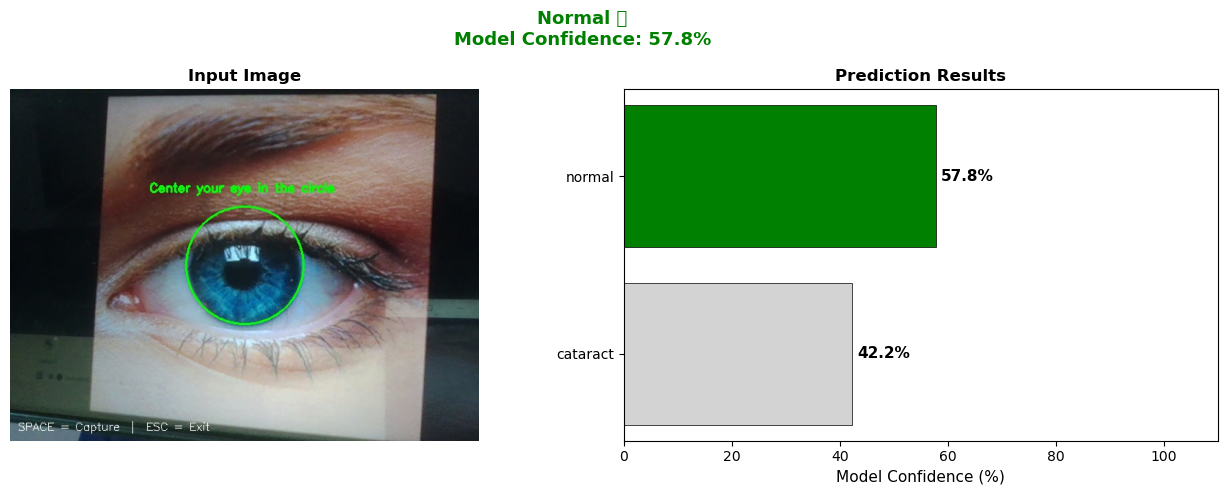


📋 Result Summary:
   Diagnosis        : Normal ✅
   Model Confidence : 57.8%


('normal', np.float32(57.77553))

In [13]:
def capture_and_predict(model, class_names, save_path='captured_eye.jpg', img_size=224):
    """
    Open camera, capture image, and predict directly.
    Press SPACE to capture.
    Press ESC to exit without capturing.
    """
    print('📷 Opening camera...')
    print('   Press SPACE to capture')
    print('   Press ESC to exit')

    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print('❌ Cannot open camera! Make sure it is connected.')
        return

    # Set camera resolution
    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

    captured      = False
    frame_to_save = None

    while True:
        ret, frame = cap.read()
        if not ret:
            print('❌ Cannot read from camera!')
            break

        h, w = frame.shape[:2]
        cx, cy = w // 2, h // 2

        # Draw guide circle in the center
        cv2.circle(frame, (cx, cy), 80, (0, 255, 0), 2)
        cv2.putText(frame, 'Center your eye in the circle',
                   (cx - 130, cy - 100),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2)
        cv2.putText(frame, 'SPACE = Capture  |  ESC = Exit',
                   (10, h - 15),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        cv2.imshow('Eye Camera', frame)

        key = cv2.waitKey(1) & 0xFF
        if key == 32:   # SPACE
            frame_to_save = frame.copy()
            captured = True
            print('📸 Image captured!')
            break
        elif key == 27:  # ESC
            print('❌ Cancelled.')
            break

    cap.release()
    cv2.destroyAllWindows()

    if captured and frame_to_save is not None:
        cv2.imwrite(save_path, frame_to_save)
        print(f'💾 Image saved to: {save_path}')
        print('\n🔍 Running prediction...')
        return predict_eye_disease(save_path, model, class_names, img_size)
    else:
        print('No image captured.')
        return None


# ✅ Run camera
capture_and_predict(model, CLASS_NAMES)

## Cell 14 - Save Final Model

In [14]:
# Save model
model.save('eye_disease_model_final.h5')
print('✅ Model saved as: eye_disease_model_final.h5')

# Save class names
import json
with open('class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)
print('✅ Class names saved as: class_names.json')

print('\n📦 Files saved:')
print('   - eye_disease_model_final.h5  (Final model)')
print('   - best_eye_model.h5           (Best model during training)')
print('   - class_names.json            (Class names)')
print('   - training_history.png        (Training curves)')
print('   - confusion_matrix.png        (Confusion matrix)')

✅ Model saved as: eye_disease_model_final.h5
✅ Class names saved as: class_names.json

📦 Files saved:
   - eye_disease_model_final.h5  (Final model)
   - best_eye_model.h5           (Best model during training)
   - class_names.json            (Class names)
   - training_history.png        (Training curves)
   - confusion_matrix.png        (Confusion matrix)


## Cell 15 - Load & Use Saved Model

In [ ]:
# Load saved model for later use
from tensorflow.keras.models import load_model

# Load model
loaded_model = load_model('eye_disease_model_final.h5')

# Load class names
with open('class_names.json', 'r') as f:
    loaded_class_names = json.load(f)

print('✅ Model loaded successfully!')
print(f'   Classes: {loaded_class_names}')

# Use for prediction
# diagnosis, conf = predict_eye_disease('path/to/image.jpg', loaded_model, loaded_class_names)